<a href="https://colab.research.google.com/github/utkarsh6174/kaggle-competitions-solutions/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import imp ml libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier



In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#basic stylings to set for sns for plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)


In [ ]:
#load the dataset
train  = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f"Training set shape: {train.shape}")
print(f"Test set shape: {test.shape}")

#print first 5 rows
train.head()


Training set shape: (891, 12)
Test set shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
#calculate and see the missing values
print("Missing values in training set: ")
print(train.isnull().sum())

print("\nOverall survival rate:", train['Survived'].mean())
print("\nOverall average age:", train['Age'].mean())

Missing values in training set: 
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Overall survival rate: 0.3838383838383838

Overall average age: 29.69911764705882


In [ ]:
print("Missing values in test set")
print(test.isnull().sum())

Missing values in test set
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [ ]:
#now exploratry data analysis (eda)

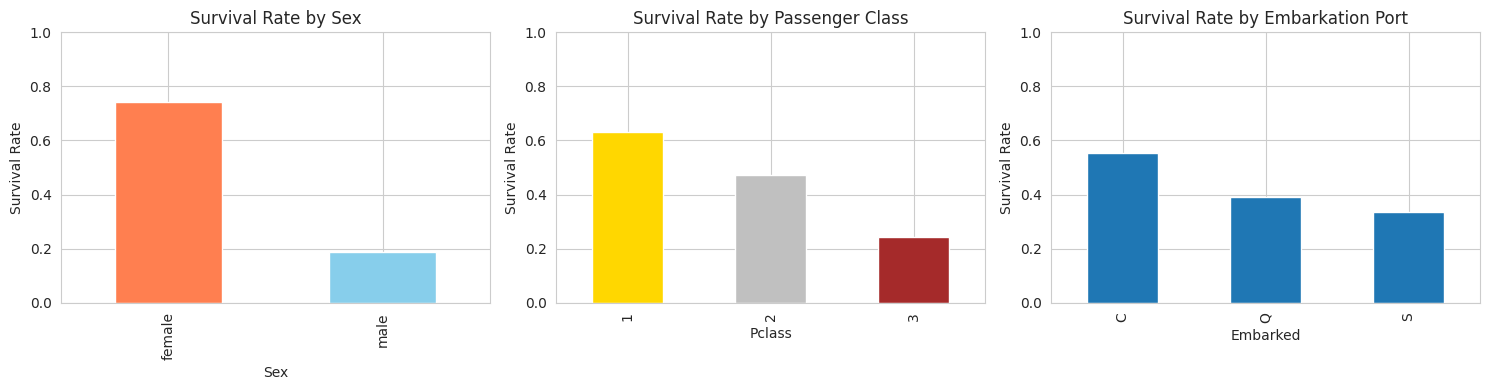

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# By Sex
train.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[0], color=['coral', 'skyblue'])
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)

# By Class
train.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[1], color=['gold', 'silver', 'brown'])
axes[1].set_title('Survival Rate by Passenger Class')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)

# By Embarked
train.groupby('Embarked')['Survived'].mean().plot(kind='bar', ax=axes[2])
axes[2].set_title('Survival Rate by Embarkation Port')
axes[2].set_ylabel('Survival Rate')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()


In [ ]:
#as cabin column has 687 missing values which is too much so we have to drop that column

In [ ]:
def extract_title(name):
  """Extract title from passenger name"""
  title  = name.split(',')[1].split('.')[0].strip()
  #group rare titles
  if title in ['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']:
      return 'Rare'
  elif title in ['Mlle', 'Ms']:
      return 'Miss'
  elif title == 'Mme':
      return 'Mrs'
  return title

In [ ]:
def engineer_features(df):
  df = df.copy()
  df['Title'] = df['Name'].apply(extract_title)
  df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
  df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
  df['Age'] = df['Age'].fillna(df['Age'].median())
  df['Fare'] = df['Fare'].fillna(df['Fare'].median())
  df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
  return df

# Apply feature engineering
train_fe = engineer_features(train)
test_fe = engineer_features(test)

print("New features created!")
print(train_fe[['Name', 'Title', 'FamilySize', 'IsAlone']].head())


New features created!
                                                Name Title  FamilySize  \
0                            Braund, Mr. Owen Harris    Mr           2   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...   Mrs           2   
2                             Heikkinen, Miss. Laina  Miss           1   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)   Mrs           2   
4                           Allen, Mr. William Henry    Mr           1   

   IsAlone  
0        0  
1        0  
2        1  
3        0  
4        1  


In [ ]:
feature_columns = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title']

# Combine train and test for consistent encoding
combined = pd.concat([train_fe[feature_columns], test_fe[feature_columns]], axis=0)

# Convert categorical variables to numeric (one-hot encoding)
combined_encoded = pd.get_dummies(combined, columns=['Sex', 'Embarked', 'Title'], drop_first=True)

In [ ]:
X_train = combined_encoded[:len(train_fe)]
X_test = combined_encoded[len(train_fe):]
y_train = train_fe['Survived']

In [ ]:
print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")
print(f"\nFeatures used: {list(X_train.columns)}")

Training features shape: (891, 13)
Test features shape: (418, 13)

Features used: ['Pclass', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Title_the Countess']


In [ ]:
lr_model  = LogisticRegression(max_iter= 1000, random_state = 42)

#cross validation to evaluate model
lr_cv_scores = cross_val_score(lr_model , X_train, y_train , cv=5 , scoring = 'accuracy')
print("Logistic Regression Cross-Validation Scores: ")
print(f"Individual folds: {lr_cv_scores}")
print(f" Mean CV accuracy: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std():.4f})")

#train on full training set
lr_model.fit(X_train, y_train)
print("\nLogistic regression trained!")


Logistic Regression Cross-Validation Scores: 
Individual folds: [0.81564246 0.82022472 0.80898876 0.79775281 0.84831461]
 Mean CV accuracy: 0.8182 (+/- 0.0169)

Logistic regression trained!


In [ ]:
lr_predictions = lr_model.predict(X_test)

print(f"Predictions made:  {len(lr_predictions)}")
print(f"Predicted survival rate: {lr_predictions.mean():.2%}")

Predictions made:  418
Predicted survival rate: 39.23%


In [ ]:
lr_submission  = pd.DataFrame({
    'PassengerId': test_fe['PassengerId'],
    'Survived' : lr_predictions
})
lr_submission.to_csv('submission_logistic_regression.csv',index = False)

In [ ]:
#decision tree classifier

dt_model = DecisionTreeClassifier(
    max_depth = 5,
    min_samples_split = 20,
    min_samples_leaf = 10,
    random_state  = 42
)
#cross validation
dt_cv_scores = cross_val_score(dt_model, X_train , y_train , cv = 5 , scoring = 'accuracy')
print("Decision Tree Cross-Validation Scores:")
print(f"  Individual folds: {dt_cv_scores}")
print(f"  Mean CV Accuracy: {dt_cv_scores.mean():.4f} (+/- {dt_cv_scores.std():.4f})")

# Train on full training set
dt_model.fit(X_train, y_train)
print("\nDecision Tree trained!")


Decision Tree Cross-Validation Scores:
  Individual folds: [0.77094972 0.78651685 0.83707865 0.78089888 0.83146067]
  Mean CV Accuracy: 0.8014 (+/- 0.0274)

Decision Tree trained!


In [ ]:
dt_predictions = dt_model.predict(X_test)

print(f"Predictions made: {len(dt_predictions)}")
print(f"Predicted survival rate: {dt_predictions.mean():.2%}")

# Create submission file
dt_submission = pd.DataFrame({
    'PassengerId': test_fe['PassengerId'],
    'Survived': dt_predictions
})
dt_submission.to_csv('submission_decision_tree.csv', index=False)

print("\n✓ Submission file created: submission_decision_tree.csv")
print(f"  Shape: {dt_submission.shape}")
print("\nSubmit this second to see if it improves over logistic regression!")

Predictions made: 418
Predicted survival rate: 37.80%

✓ Submission file created: submission_decision_tree.csv
  Shape: (418, 2)

Submit this second to see if it improves over logistic regression!


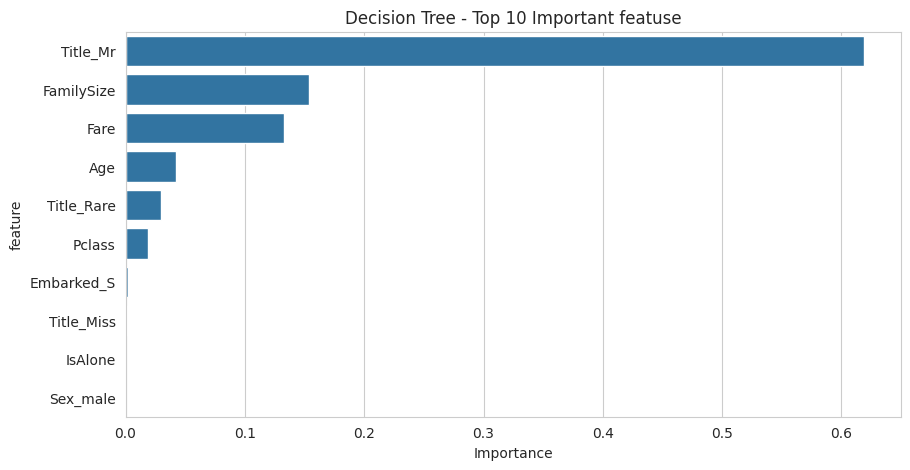

       feature  importance
9     Title_Mr    0.618543
3   FamilySize    0.153965
2         Fare    0.133012
1          Age    0.041901
11  Title_Rare    0.029455
0       Pclass    0.019128
7   Embarked_S    0.002374
8   Title_Miss    0.001622
4      IsAlone    0.000000
5     Sex_male    0.000000


In [ ]:
#Feature importance for Decision Tree

dt_importance = pd.DataFrame({
    'feature' : X_train.columns,
    'importance': dt_model.feature_importances_

}).sort_values('importance',ascending = False)

plt.figure(figsize= (10,5))
sns.barplot(data = dt_importance.head(10),x = 'importance' , y = 'feature')
plt.title('Decision Tree - Top 10 Important featuse')
plt.xlabel('Importance')
plt.show()
print(dt_importance.head(10))

In [ ]:
# random forest classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)

# Cross-validation
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
print("Random Forest Cross-Validation Scores:")
print(f"  Individual folds: {rf_cv_scores}")
print(f"  Mean CV Accuracy: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")

# Train on full training set
rf_model.fit(X_train, y_train)
print("\nRandom Forest trained!")


Random Forest Cross-Validation Scores:
  Individual folds: [0.82122905 0.81460674 0.84269663 0.80337079 0.86516854]
  Mean CV Accuracy: 0.8294 (+/- 0.0220)

Random Forest trained!


In [ ]:
rf_predictions = rf_model.predict(X_test)

print(f"Predictions made: {len(rf_predictions)}")
print(f"Predicted survival rate: {rf_predictions.mean():.2%}")

# Create submission file
rf_submission = pd.DataFrame({
    'PassengerId': test_fe['PassengerId'],
    'Survived': rf_predictions
})
rf_submission.to_csv('submission_random_forest.csv', index=False)

print("\n✓ Submission file created: submission_random_forest.csv")
print(f"  Shape: {rf_submission.shape}")
print("\nSubmit this third to see the best performance!")


Predictions made: 418
Predicted survival rate: 36.84%

✓ Submission file created: submission_random_forest.csv
  Shape: (418, 2)

Submit this third to see the best performance!
